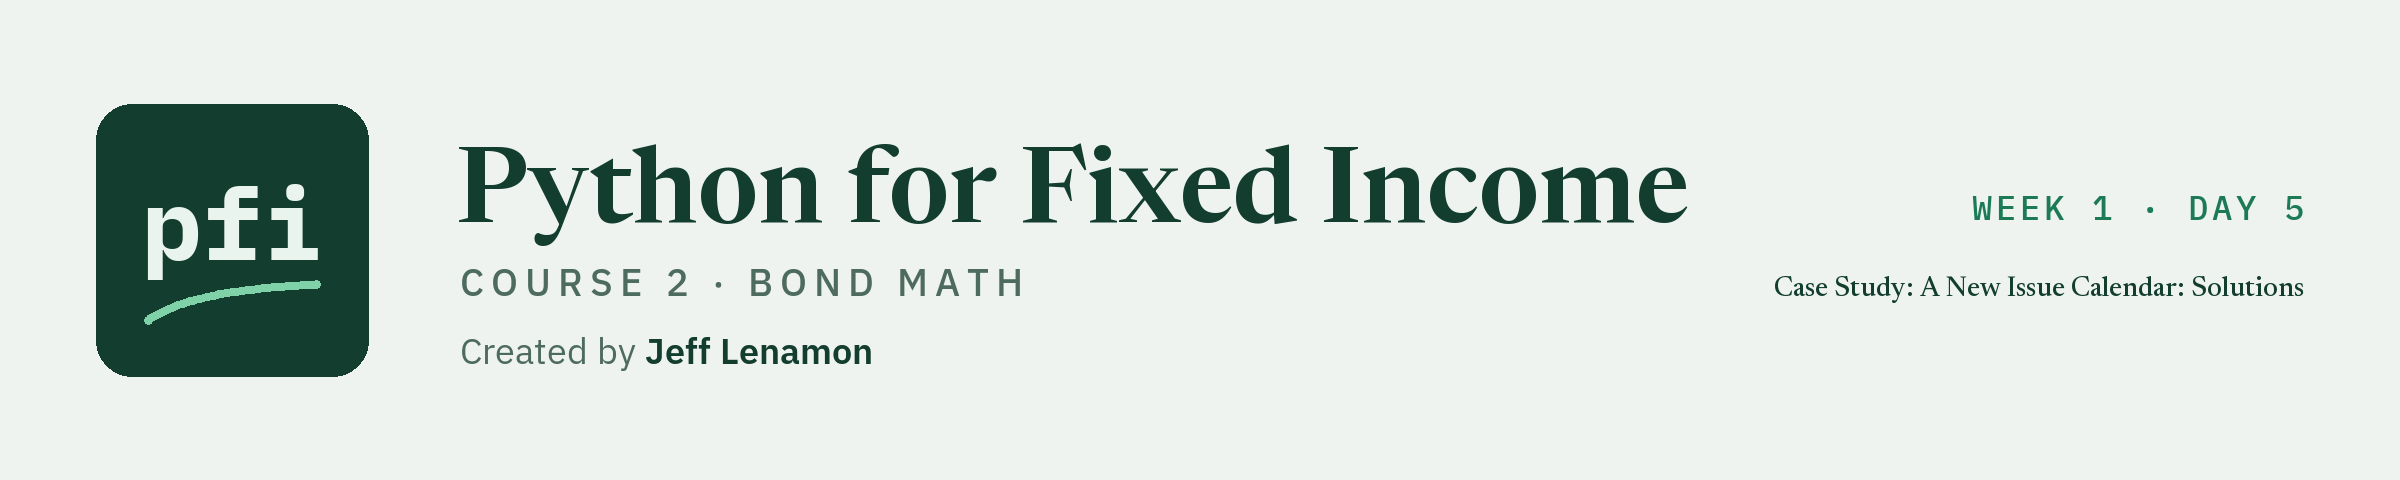

# Case Study: A New Issue Calendar: Solutions

Week 1, Day 5. Worked answers to the exercises. Try each one yourself first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course2_bond_math/week1/day5/05_case_study_a_new_issue_calendar_solutions.ipynb)

This notebook stands on its own. Its setup writes `bondmath.py` and `test_bondmath.py` as they stand at the end of today, so the exercises can be run without the lesson.

Q. Set up today's work folder.

In [1]:
# modules that come with Python: folders and files, the temp folder, running programs, reloading a module
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# pytest runs the tests. A Colab runtime may not have it.
try:
    import pytest
except ImportError:
    raise RuntimeError("pytest is not installed. Run  !pip install pytest  in a new cell, then run this cell again.") from None

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "bondmath_excel_reference.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course2_05_"))
os.chdir(work)

# 3. copy the two Excel reference files into the work folder
for name in ["bondmath_excel_reference.csv", "bondmath_excel_reference_tvm.csv"]:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Reference files copied from: {'GitHub' if on_github else 'the data folder of the course repo'}")
print(f"pytest version: {pytest.__version__}")

Work folder: pfi_course2_05_5u7bm6pq, in your temp folder
Reference files copied from: the data folder of the course repo
pytest version: 9.1.1


Q. Write `bondmath.py` and `test_bondmath.py` as they stand at the end of today.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100


def yield_from_price(coupon_pct: float, price: float, years: float, frequency: int = 2) -> float:
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

    Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
    Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
    The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price_from_yield(coupon_pct, low_pct, years, frequency)
    lowest_price = price_from_yield(coupon_pct, high_pct, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price_from_yield(coupon_pct, mid_pct, years, frequency) > price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2

Writing bondmath.py


In [3]:
%%writefile test_bondmath.py
"""Tests for bondmath.py.

Every expected value comes from Excel: the two reference CSV files in this folder, or a small hand
table whose values those files confirm. Run from this folder with:  python -m pytest
"""
import csv
import math  # used from week 3
from datetime import date  # used from week 2
from pathlib import Path

import pytest

import bondmath

# the reference files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_rows(file_name: str) -> list[dict]:
    """Read a reference CSV from this folder: one dict per row, every value a string."""
    with open(HERE / file_name, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


TVM = read_rows("bondmath_excel_reference_tvm.csv")


def tvm_rows(function: str) -> list[dict]:
    """The week 1 reference rows for one Excel function, for example "FV"."""
    rows = [row for row in TVM if row["function"] == function]
    assert rows, f"no {function} rows in the reference file"
    return rows


def test_future_value_matches_excel_fv():
    for row in tvm_rows("FV"):
        # the inputs, in course units
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.future_value(amount, rate_pct, years, frequency)
        # Excel's FV, with the amount entered as -amount, is positive
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_matches_excel_pv():
    for row in tvm_rows("PV"):
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.present_value(amount, rate_pct, years, frequency)
        # Excel's PV of a positive amount is negative (money paid now), so compare with minus the Excel value
        assert result == pytest.approx(-float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_undoes_future_value():
    for frequency in (1, 2, 4):
        # grow 100 for 3 years at 5 percent, then discount it back
        grown = bondmath.future_value(100, 5.0, 3, frequency)
        assert bondmath.present_value(grown, 5.0, 3, frequency) == pytest.approx(100, abs=1e-9)


REFERENCE = read_rows("bondmath_excel_reference.csv")


def test_cash_flows_count_and_final_flow():
    flows = bondmath.cash_flows(6.0, 5, 2)
    # 5 years of half-year coupons is 10 cash flows
    assert len(flows) == 10
    # the first is a 3.00 coupon after half a year, the last is the coupon plus the face at 5 years
    assert flows[0] == pytest.approx((0.5, 3.0))
    assert flows[-1] == pytest.approx((5.0, 103.0))


def test_cash_flows_raises_on_part_periods():
    # 2.3 years is not a whole number of half years, so cash_flows must stop with a ValueError
    try:
        bondmath.cash_flows(6.0, 2.3, 2)
    except ValueError:
        return
    assert False, "cash_flows accepted 2.3 years at frequency 2"


def test_price_from_yield_matches_excel():
    # Excel's -PV with a coupon: a bond priced on a coupon date
    for row in tvm_rows("PV_BOND"):
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["rate_pct"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]
    # Excel's PRICE on the rows that settle on a coupon date (no days accrued)
    coupon_date_rows = [row for row in REFERENCE if row["coupdaybs"] == "0"]
    assert coupon_date_rows, "no coupon-date rows in the reference file"
    for row in coupon_date_rows:
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["yield_pct"]), years, frequency)
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_convert_yield_matches_excel_effect_and_nominal():
    # EFFECT restates a rate compounded `frequency` times a year as an annually compounded rate
    for row in tvm_rows("EFFECT"):
        result = bondmath.convert_yield(float(row["rate_pct"]), int(row["frequency"]), 1)
        # Excel returns a decimal, bondmath a percent
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]
    # NOMINAL goes the other way: from annual compounding to `frequency` times a year
    for row in tvm_rows("NOMINAL"):
        result = bondmath.convert_yield(float(row["rate_pct"]), 1, int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]


def test_convert_yield_round_trip():
    # semiannual to quarterly and back gives the yield we started with
    quarterly = bondmath.convert_yield(6.0, 2, 4)
    assert bondmath.convert_yield(quarterly, 4, 2) == pytest.approx(6.0, abs=1e-12)


def test_yield_from_price_matches_excel():
    # Excel's RATE, times the frequency, is the annual yield as a decimal
    for row in tvm_rows("RATE"):
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-6), row["case_id"]
    # Excel's YIELD on the coupon-date rows, already in percent in the reference file
    for row in REFERENCE:
        if row["coupdaybs"] != "0":
            continue
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]), years, frequency)
        assert result == pytest.approx(float(row["yield_pct_from_price"]), abs=1e-6), row["case_id"]


def test_yield_raises_outside_bracket():
    # no yield between -5 and 100 percent gives a price of 1,000 or of 0.01
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 1000.0, 5, 2)
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 0.01, 5, 2)


def test_yield_round_trip():
    # price a bond from a yield, then solve the yield back from that price
    bond_price = bondmath.price_from_yield(5.25, 6.1, 7, 2)
    assert bondmath.yield_from_price(5.25, bond_price, 7, 2) == pytest.approx(6.1, abs=1e-8)


def test_par_bond_prices_at_100():
    # a coupon equal to the yield prices at 100 for every frequency and term
    for frequency in (1, 2, 4):
        for years in (1, 2, 5, 10, 30):
            assert bondmath.price_from_yield(5.5, 5.5, years, frequency) == pytest.approx(100, abs=1e-9)


def test_price_falls_as_yield_rises():
    # price a 10-year 6 percent bond at yields from 2 to 12 percent
    prices = [bondmath.price_from_yield(6.0, yield_pct, 10, 2) for yield_pct in (2, 4, 6, 8, 10, 12)]
    # every price is below the one before it
    for earlier, later in zip(prices, prices[1:]):
        assert later < earlier

Writing test_bondmath.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)

# the functions defined in the module itself, not the ones it imports
functions = [name for name, obj in vars(bondmath).items() if callable(obj) and getattr(obj, "__module__", "") == "bondmath"]
print(f"bondmath functions: {functions}")

bondmath functions: ['future_value', 'present_value', 'cash_flows', 'price_from_yield', 'convert_yield', 'yield_from_price']


## Exercises

The exercises use a second calendar: five more invented new issues, settling on 30 September 2026 like the first eight. The issuers and every number are invented, and every answer describes the data.

| CUSIP | Issuer | Rating | Coupon (%) | Years | Maturity | Re-offer price |
| --- | --- | --- | --- | --- | --- | --- |
| 99021VZA9 | Feskundra Systems | A+ | 4.5 | 4 | 2030-09-30 | 99.850 |
| 99022WZA6 | Krilorin Logistics | BBB- | 6.25 | 7 | 2033-09-30 | 99.375 |
| 99023XZA3 | Dralundra Brands | A+ | 4.25 | 2 | 2028-09-30 | 100.000 |
| 99024YZA0 | Vyrerone Metals | BB+ | 7.25 | 8 | 2034-09-30 | 99.000 |
| 99026AZA0 | Nevovar Energy | BBB- | 6.125 | 12 | 2038-09-30 | 99.625 |

Replace each `...` with your own code, then run the check cell. Print the numbers you rely on with f-strings. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It types in the second calendar and defines `check`, a small function that marks your answers.

In [5]:
exercise_calendar = pd.DataFrame({
    "cusip": ['99021VZA9', '99022WZA6', '99023XZA3', '99024YZA0', '99026AZA0'],
    "issuer": ['Feskundra Systems', 'Krilorin Logistics', 'Dralundra Brands', 'Vyrerone Metals', 'Nevovar Energy'],
    "ticker": ['FESA', 'KRIN', 'DRAA', 'VYRE', 'NEVR'],
    "rating": ['A+', 'BBB-', 'A+', 'BB+', 'BBB-'],
    # the annual coupon in percent, and the years from settlement on 30 September 2026 to maturity
    "coupon_pct": [4.5, 6.25, 4.25, 7.25, 6.125],
    "years": [4, 7, 2, 8, 12],
    "maturity": ['2030-09-30', '2033-09-30', '2028-09-30', '2034-09-30', '2038-09-30'],
    # the re-offer price, per 100 of face
    "reoffer_price": [99.85, 99.375, 100.0, 99.0, 99.625],
})


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")


exercise_calendar

,cusip,issuer,ticker,rating,coupon_pct,years,maturity,reoffer_price
0,99021VZA9,Feskundra Systems,FESA,A+,4.500,4,2030-09-30,99.850
1,99022WZA6,Krilorin Logistics,KRIN,BBB-,6.250,7,2033-09-30,99.375
2,99023XZA3,Dralundra Brands,DRAA,A+,4.250,2,2028-09-30,100.000
3,99024YZA0,Vyrerone Metals,VYRE,BB+,7.250,8,2034-09-30,99.000
4,99026AZA0,Nevovar Energy,NEVR,BBB-,6.125,12,2038-09-30,99.625


### Exercise 1

Q. With `bondmath.yield_from_price`, find the yield of each issue on the second calendar from its re-offer price, and how far each yield is above its coupon in basis points. Store Nevovar Energy's yield, in percent and unrounded, in **ex1_nevovar**, and in **ex1_widest** the ticker whose yield is furthest above its coupon.

In [6]:
exercise_calendar["yield_pct"] = [
    bondmath.yield_from_price(c, p, t)
    for c, p, t in zip(exercise_calendar["coupon_pct"], exercise_calendar["reoffer_price"], exercise_calendar["years"])
]
exercise_calendar["yield_minus_coupon_bp"] = (exercise_calendar["yield_pct"] - exercise_calendar["coupon_pct"]) * 100
print(exercise_calendar[["ticker", "coupon_pct", "years", "reoffer_price", "yield_pct", "yield_minus_coupon_bp"]].round(4))

ex1_nevovar = exercise_calendar.loc[exercise_calendar["ticker"] == "NEVR", "yield_pct"].iloc[0]
# idxmax gives the row label of the largest value
ex1_widest = exercise_calendar.loc[exercise_calendar["yield_minus_coupon_bp"].idxmax(), "ticker"]

print(f"Nevovar yields {ex1_nevovar:.4f} percent. Furthest above its coupon: {ex1_widest}")

  ticker  coupon_pct  years  reoffer_price  yield_pct  yield_minus_coupon_bp
0   FESA       4.500      4         99.850     4.5414                 4.1432
1   KRIN       6.250      7         99.375     6.3620                11.2028
2   DRAA       4.250      2        100.000     4.2500                 0.0000
3   VYRE       7.250      8         99.000     7.4180                16.7976
4   NEVR       6.125     12         99.625     6.1697                 4.4691
Nevovar yields 6.1697 percent. Furthest above its coupon: VYRE


* Nevovar at 99.625 yields 6.1697 percent, 4.5 basis points above its coupon.
* Vyrerone, an 8-year bond a full point below 100, is furthest above its coupon, 16.8 basis points. Krilorin, 7 years at 99.375, is next at 11.2. Dralundra, at 100, yields its coupon.
* Excel agrees: `=YIELD(DATE(2026,9,30),DATE(2038,9,30),6.125/100,99.625,100,2,0)` returns 0.06169691301406604.

In [7]:
check("Exercise 1 Nevovar yield", ex1_nevovar, 6.169691301427065)
check("Exercise 1 furthest above its coupon", ex1_widest, "VYRE")

Exercise 1 Nevovar yield: correct
Exercise 1 furthest above its coupon: correct


### Exercise 2

Q. Price every issue on the second calendar at the common yield of 5.50 percent, and find what one eighth more coupon adds to each price at that yield. Store Krilorin Logistics' price at 5.50 percent in **ex2_krilorin**, and the price effect of one eighth of coupon on Nevovar Energy in **ex2_step_nevovar**, both per 100 of face and unrounded.

In [8]:
common_yield_pct = 5.5
exercise_calendar["price_at_5_50"] = [
    bondmath.price_from_yield(c, common_yield_pct, t) for c, t in zip(exercise_calendar["coupon_pct"], exercise_calendar["years"])
]
exercise_calendar["step_value"] = [
    bondmath.price_from_yield(c + 0.125, common_yield_pct, t) - bondmath.price_from_yield(c, common_yield_pct, t)
    for c, t in zip(exercise_calendar["coupon_pct"], exercise_calendar["years"])
]
print(exercise_calendar[["ticker", "coupon_pct", "years", "price_at_5_50", "step_value"]].round(4))

ex2_krilorin = exercise_calendar.loc[exercise_calendar["ticker"] == "KRIN", "price_at_5_50"].iloc[0]
ex2_step_nevovar = exercise_calendar.loc[exercise_calendar["ticker"] == "NEVR", "step_value"].iloc[0]

print(f"Krilorin at 5.50 percent: {ex2_krilorin:.4f}. One eighth of coupon on Nevovar: {ex2_step_nevovar:.4f}")

  ticker  coupon_pct  years  price_at_5_50  step_value
0   FESA       4.500      4        96.4528      0.4434
1   KRIN       6.250      7       104.3091      0.7182
2   DRAA       4.250      2        97.6629      0.2337
3   VYRE       7.250      8       111.2040      0.8003
4   NEVR       6.125     12       105.4377      1.0875
Krilorin at 5.50 percent: 104.3091. One eighth of coupon on Nevovar: 1.0875


* Krilorin's 6.25 percent coupon is above 5.50, so it prices above 100, at 104.3091. Feskundra and Dralundra pay less than 5.50 and price below 100.
* One eighth of coupon is worth 1.0875 on Nevovar's 12 years, against 0.2337 on Dralundra's 2. Krilorin's step, 0.7182, equals Hulvimer's on the first calendar, another 7-year bond: same term, same yield, same step.
* Excel agrees: `=PRICE(DATE(2026,9,30),DATE(2033,9,30),6.25/100,5.5/100,100,2,0)` returns 104.3091280509253.

In [9]:
check("Exercise 2 Krilorin price at 5.50", ex2_krilorin, 104.30912805092527)
check("Exercise 2 Nevovar step", ex2_step_nevovar, 1.0875497936428076)

Exercise 2 Krilorin price at 5.50: correct
Exercise 2 Nevovar step: correct


### Exercise 3

Q. Add a function to your module. `par_coupon_pct(yield_pct, step=0.125)` returns the coupon on a grid of `step` that prices nearest par at `yield_pct`, on a coupon date: section 5.3 showed it is the grid coupon nearest the yield. A yield exactly halfway between two grid coupons goes to the higher one, as Excel's `MROUND` does, and a yield or step of zero or below raises `ValueError`. Write the docstring first: units, convention, and the Excel formula. Then add a test to `test_bondmath.py`, called `test_par_coupon_pct_matches_excel_mround`, that checks these yields against what Excel's `=MROUND(yield,0.125)` returns (tested in Excel): 5.43 gives 5.375, 5.69 gives 5.75, 9.08 gives 9.125, 4.55 gives 4.5, and the two exact ties 5.0625 gives 5.125 and 4.9375 gives 5.0; and that a yield of zero raises `ValueError`. Run pytest, and store the list of `par_coupon_pct` of each yield from Exercise 1, in the calendar's order, in **ex3_coupons**.

Write the function in the cell that starts with `%%writefile -a bondmath.py` and the test in the one that starts with `%%writefile -a test_bondmath.py`, and run each of those cells once. Then reload the module.

In [10]:
%%writefile -a bondmath.py


def par_coupon_pct(yield_pct: float, step: float = 0.125) -> float:
    """The coupon on a grid of `step` that prices nearest par at yield_pct, on a coupon date.

    Units: yield_pct and step in percent; returns the coupon in percent.
    Convention: a bond whose coupon equals its yield prices at 100, and price is a straight line in the
    coupon, so the grid coupon nearest the yield prices nearest par. A yield exactly halfway between two
    grid coupons goes to the higher one. Raises ValueError unless yield_pct and step are above zero.
    Excel: =MROUND(yield_pct, step)
    """
    # stop on a yield or a step the rule does not cover
    if yield_pct <= 0 or step <= 0:
        raise ValueError(f"yield_pct and step must be above zero, not {yield_pct} and {step}")
    # count the steps in the yield, add a half, and keep the whole part: rounding half up
    whole_steps = int(yield_pct / step + 0.5)
    return whole_steps * step

Appending to bondmath.py


In [11]:
%%writefile -a test_bondmath.py


def test_par_coupon_pct_matches_excel_mround():
    # a hand table confirmed by Excel's =MROUND(yield,0.125); the last two are exact ties, which go up
    cases = [(5.43, 5.375), (5.69, 5.75), (9.08, 9.125), (4.55, 4.5), (5.0625, 5.125), (4.9375, 5.0)]
    for yield_pct, expected in cases:
        assert bondmath.par_coupon_pct(yield_pct) == pytest.approx(expected, abs=1e-12), yield_pct
    # a yield of zero has no coupon on the grid
    with pytest.raises(ValueError):
        bondmath.par_coupon_pct(0.0)

Appending to test_bondmath.py


In [12]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

..............                                                           [100%]
14 passed in 0.07s



In [13]:
# the file changed, so reload before calling the new function
importlib.reload(bondmath)

ex3_coupons = [bondmath.par_coupon_pct(y) for y in exercise_calendar["yield_pct"]]
print(f"Grid coupons nearest par: {ex3_coupons}")
print(f"Calendar coupons:         {exercise_calendar['coupon_pct'].tolist()}")

Grid coupons nearest par: [4.5, 6.375, 4.25, 7.375, 6.125]
Calendar coupons:         [4.5, 6.25, 4.25, 7.25, 6.125]


* `14 passed`: the 13 tests of the lesson and the new one.
* For Krilorin Logistics and Vyrerone Metals, the grid coupon nearest par is one eighth above the calendar's, as for Galvostrin and Rulvolvey on the first calendar. The other three keep their coupons.
* `int(yield_pct / step + 0.5)` rounds half up for a positive number: `int` drops the decimals, and adding a half first turns a remainder of a half or more into one more step. For 5.0625, 40.5 steps plus a half is 41 exactly, so the tie goes up, to 5.125, as `MROUND` returns.
* `int` drops decimals towards zero, so this rounding is wrong for a negative number. The check that stops on a yield of zero or below keeps the function inside the range where it is right.
* In Excel: `=MROUND(B1,0.125)` with the yield in percent in B1.

In [14]:
check("Exercise 3 grid coupons nearest par", ex3_coupons, [4.5, 6.375, 4.25, 7.375, 6.125])

Exercise 3 grid coupons nearest par: correct


### Exercise 4: AI check

You ask an AI assistant to write `price_from_yield` for you, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Price of a bullet bond on a coupon date, from its yield.

Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug: a convention error.

* The bug: the code works per 1 of face. It turns the coupon into a decimal, coupon_pct / 100 / frequency, and pays back a face of 1 at the end. The docstring promises the price per 100 of face. Rulvolvey at 5.50 percent came back as 1.073057 instead of 107.3057: exactly a hundredth.
* The test caught it on the first `CALENDAR_PRICE` row, `tvm_calendar_price_01`: 0.983800 against Excel's 98.379986.
* Today's `test_price_falls_as_yield_rises` would not have caught it. Dividing every price by 100 keeps every comparison the same way round, so prices still fall as yields rise. A test that compares numbers with Excel's catches a unit error; a test of a rule may not.
* The fix, in the cell below: keep the coupon per 100 of face, coupon_pct / frequency, and pay back 100 at the end.

In [15]:
def assistant_price_from_yield(coupon_pct, yield_pct, years, frequency=2):
    """Price of a bullet bond on a coupon date, from its yield.

Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period as a decimal; the coupon for one period per 100 of face
    period_yield = yield_pct / 100 / frequency
    # the fix: the docstring promises price per 100 of face, so the coupon stays per 100 and the face is 100
    period_coupon = coupon_pct / frequency
    periods = round(years * frequency)
    price = 0.0
    for k in range(1, periods + 1):
        # each coupon, and the face of 100 back with the last one
        amount = period_coupon + 100 if k == periods else period_coupon
        price += amount / (1 + period_yield) ** k
    return price

In [16]:
# the test, written from Excel's reference rows before the code is trusted
tvm = pd.read_csv("bondmath_excel_reference_tvm.csv")
price_rows = tvm[tvm["function"] == "CALENDAR_PRICE"]

# each row is Excel's PRICE of one calendar issue at 5.50 percent, per 100 of face
for row in price_rows.itertuples():
    result = assistant_price_from_yield(row.coupon_pct, row.rate_pct, row.years, int(row.frequency))
    assert abs(result - row.excel_value) < 1e-6, f"{row.case_id}: {result:.6f} against Excel's {row.excel_value:.6f}"

print(f"All {len(price_rows)} CALENDAR_PRICE rows match Excel")

All 21 CALENDAR_PRICE rows match Excel


In [17]:
ex4_rulvolvey = assistant_price_from_yield(6.0, 5.5, 30)
ex4_rows = len(price_rows)

print(f"Rulvolvey at 5.50 percent from the fixed function: {ex4_rulvolvey:.4f}")
print(f"CALENDAR_PRICE rows checked: {ex4_rows}")

Rulvolvey at 5.50 percent from the fixed function: 107.3057
CALENDAR_PRICE rows checked: 21


* 107.3057, the price from section 5.2, and all 21 rows match. The fixed function now does what its docstring says: the price per 100 of face.

In [18]:
check("Exercise 4 Rulvolvey price", ex4_rulvolvey, 107.30566550271641)
check("Exercise 4 rows checked", ex4_rows, 21)

Exercise 4 Rulvolvey price: correct
Exercise 4 rows checked: correct


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```